<a href="https://colab.research.google.com/github/jihyeon602/Statics-Machine_Learning/blob/main/DACON_%EC%8B%A0%EC%95%BD%EA%B0%9C%EB%B0%9C%EC%98%88%EC%B8%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 25.06.30 2차 정기 평가 - 박지현
- Boost up AI 2025 : 신약 개발 경진대회


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### EDA
- TRIAN: 1681, 3
- TEST: 100, 2
- X: Canonical_Smiles
- y: Inhibition ( CYP3A4 효소 저해율(%))

In [5]:
train_df = pd.read_csv('/content/train.csv')
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1681 entries, 0 to 1680
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                1681 non-null   object 
 1   Canonical_Smiles  1681 non-null   object 
 2   Inhibition        1681 non-null   float64
dtypes: float64(1), object(2)
memory usage: 39.5+ KB


In [6]:
print(train_df.head())
print(train_df.tail())

           ID                                   Canonical_Smiles  Inhibition
0  TRAIN_0000                        Cl.OC1(Cc2cccc(Br)c2)CCNCC1       12.50
1  TRAIN_0001                              Brc1ccc2OCCc3ccnc1c23        4.45
2  TRAIN_0002         CC1(CO)CC(=NO1)c2cc(c(F)cc2Cl)[N+](=O)[O-]        4.92
3  TRAIN_0003  Fc1ccc2nc(Nc3cccc(COc4cccc(c4)C(=O)N5CCOCC5)c3...       71.50
4  TRAIN_0004       CC(C)CC(=O)C1=C(Nc2c(Cl)ccc(Cl)c2C1=O)S(=O)C       18.30
              ID                                   Canonical_Smiles  \
1676  TRAIN_1676  Cc1cc2ncn(CC3CCN(CC3)S(=O)(=O)CCN4C(=O)CCCC4=O...   
1677  TRAIN_1677          O=C(CN1N=CC=CC1=O)N2Cc3cnc(nc3C2)N4CCOCC4   
1678  TRAIN_1678               COC1=COC(=CC1=O)C(=O)Nc2cccc3c2ccn3C   
1679  TRAIN_1679       CC1=CC(=O)N(CCNC(=O)c2nc3nc(C)cc(C)n3n2)C=N1   
1680  TRAIN_1680              CCc1ccc(\C=N\Nc2nn3cnnc3c4ccccc24)cc1   

      Inhibition  
1676    0.500000  
1677    0.500000  
1678    0.500000  
1679    0.500000  
1680   41.700398

In [7]:
test_df = pd.read_csv('/content/test.csv')
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ID                100 non-null    object
 1   Canonical_Smiles  100 non-null    object
dtypes: object(2)
memory usage: 1.7+ KB


## smils 표현식 읽기

In [8]:
!pip install rdkit==2024.3.5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 65.1 MB/s eta 0:00:00


In [14]:
# RDKit: 파이썬 프로그램을 이용하여 분자 데이터를 다루는 라이브러리
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem.Draw import IPythonConsole
from rdkit.ML.Descriptors import MoleculeDescriptors

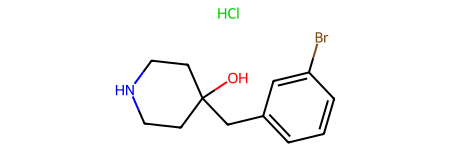

In [10]:
#test

smi = 'Cl.OC1(Cc2cccc(Br)c2)CCNCC1'
mol = Chem.MolFromSmiles(smi)

mol

### Canonical SMILES -> mol 객체로 변환

In [13]:
train_df['Mol'] = train_df["Canonical_Smiles"].apply(Chem.MolFromSmiles)
train_df['Mol'].isna().sum()

np.int64(0)

### Descriptor 계산

### train descriptor

In [ ]:
descriptor_names = [desc[0] for desc in Descriptors._descList]
calculator = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names) #Descriptor 계산기 생성
descriptor_values = [calculator.CalcDescriptors(mol) for mol in train_df["Mol"]] #계산

descriptors_df = pd.DataFrame(descriptor_values, columns=descriptor_names)
descriptors_df["ID"] = train_df["ID"].values

In [77]:
descriptors_df

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,ID,Inhibition
0,10.360274,10.360274,0.000000,-0.507894,0.879876,18.875000,306.631,289.495,305.018204,90,...,0,0,0,0,0,0,0,0,TRAIN_0000,12.500000
1,5.589676,5.589676,0.771573,0.771573,0.716687,14.071429,250.095,242.031,248.978926,70,...,0,0,0,0,0,0,0,0,TRAIN_0001,4.450000
2,13.349148,13.349148,0.007074,-1.010940,0.682701,22.000000,288.662,278.582,288.031313,102,...,0,0,0,0,0,0,0,0,TRAIN_0002,4.920000
3,13.406186,13.406186,0.013275,-0.312444,0.456076,13.787879,446.482,423.298,446.175419,168,...,0,0,0,0,0,0,0,0,TRAIN_0003,71.500000
4,12.731366,12.731366,0.079233,-1.535218,0.843664,12.818182,360.262,345.142,359.014970,118,...,0,0,0,0,0,0,0,0,TRAIN_0004,18.300000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1676,12.770901,12.770901,0.041942,-3.491998,0.634711,19.483871,446.573,416.333,446.198776,168,...,0,0,0,0,0,0,0,0,TRAIN_1676,0.500000
1677,12.473148,12.473148,0.072012,-0.289855,0.735989,16.800000,342.359,324.215,342.144038,130,...,0,0,0,0,0,0,0,0,TRAIN_1677,0.500000
1678,12.225051,12.225051,0.057140,-0.489717,0.805464,10.636364,298.298,284.186,298.095357,112,...,0,0,0,0,0,0,0,0,TRAIN_1678,0.500000
1679,12.159561,12.159561,0.046832,-0.411414,0.724643,10.958333,327.348,310.212,327.144373,124,...,0,0,0,0,0,0,0,0,TRAIN_1679,0.500000


In [16]:
descriptors_df["Inhibition"] = train_df["Inhibition"].values
descriptors_df.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,ID,Inhibition
0,10.360274,10.360274,0.000000,-0.507894,0.879876,18.875000,306.631,289.495,305.018204,90,...,0,0,0,0,0,0,0,0,TRAIN_0000,12.50
1,5.589676,5.589676,0.771573,0.771573,0.716687,14.071429,250.095,242.031,248.978926,70,...,0,0,0,0,0,0,0,0,TRAIN_0001,4.45
2,13.349148,13.349148,0.007074,-1.010940,0.682701,22.000000,288.662,278.582,288.031313,102,...,0,0,0,0,0,0,0,0,TRAIN_0002,4.92
3,13.406186,13.406186,0.013275,-0.312444,0.456076,13.787879,446.482,423.298,446.175419,168,...,0,0,0,0,0,0,0,0,TRAIN_0003,71.50
4,12.731366,12.731366,0.079233,-1.535218,0.843664,12.818182,360.262,345.142,359.014970,118,...,0,0,0,0,0,0,0,0,TRAIN_0004,18.30


In [20]:
print(descriptors_df.dtypes.value_counts())
descriptors_df.shape

float64    107
int64      104
object       1
Name: count, dtype: int64


(1681, 212)

In [21]:
descriptors_df.columns.tolist()

['MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'NumRadicalElectrons', 'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'AvgIpc', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'HallKierAlpha', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA6', 'SMR_VSA7', 'SMR_VSA8', 'SMR_VSA9', 'SlogP_VSA1', 'SlogP_VSA10', 'S

In [23]:
desc_stats = descriptors_df.describe()
desc_stats_T = desc_stats.T
desc_stats_T.to_csv("descriptor_statistics.csv", encoding="utf-8-sig", index=True)

- 전부 0값인 행은 소수 -> 삭제 하지 않는걸로

### test descriptor

In [24]:
test_df['Mol'] = test_df["Canonical_Smiles"].apply(Chem.MolFromSmiles)
test_df['Mol'].isna().sum()

np.int64(0)

In [ ]:
descriptor_values_test = [calculator.CalcDescriptors(mol) for mol in test_df["Mol"]]

test_desc_df = pd.DataFrame(descriptor_values_test, columns=descriptor_names)
test_desc_df["ID"] = test_df["ID"].values

In [76]:
test_desc_df

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,ID
0,13.677522,13.677522,0.009378,-0.847213,0.747368,23.933333,415.534,382.270,415.247107,164,...,0,0,0,0,0,0,0,0,0,TEST_000
1,5.748377,5.748377,0.335913,0.335913,0.718989,11.238095,347.216,332.096,346.042923,108,...,0,0,0,0,0,0,0,0,0,TEST_001
2,14.130702,14.130702,0.056858,-4.201489,0.544302,12.620690,417.462,397.302,417.115855,152,...,1,0,0,0,0,0,0,0,0,TEST_002
3,5.648725,5.648725,0.000000,-0.051995,0.738097,19.000000,390.875,367.691,390.157102,144,...,0,0,0,0,0,0,0,0,0,TEST_003
4,12.386907,12.386907,0.107454,-0.510619,0.607170,16.206897,460.324,438.148,459.068135,152,...,0,0,0,0,0,0,0,0,0,TEST_004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,5.465614,5.465614,0.139561,0.139561,0.900345,16.875000,348.516,320.292,348.198383,132,...,0,0,0,0,0,0,1,0,0,TEST_095
96,5.668507,5.668507,0.410621,0.410621,0.458576,14.322581,418.413,400.269,418.138953,156,...,0,0,0,0,0,0,0,0,0,TEST_096
97,6.108097,6.108097,0.140794,0.140794,0.915279,24.708333,325.408,302.224,325.167794,126,...,0,0,0,0,0,0,0,0,0,TEST_097
98,5.671890,5.671890,0.086578,-0.086578,0.783179,18.642857,385.372,366.220,385.116152,146,...,0,0,0,0,0,0,0,0,0,TEST_098


In [27]:
print(test_desc_df.shape)
print(test_desc_df.head())

(100, 211)
   MaxAbsEStateIndex  MaxEStateIndex  MinAbsEStateIndex  MinEStateIndex  \
0          13.677522       13.677522           0.009378       -0.847213   
1           5.748377        5.748377           0.335913        0.335913   
2          14.130702       14.130702           0.056858       -4.201489   
3           5.648725        5.648725           0.000000       -0.051995   
4          12.386907       12.386907           0.107454       -0.510619   

        qed        SPS    MolWt  HeavyAtomMolWt  ExactMolWt  \
0  0.747368  23.933333  415.534         382.270  415.247107   
1  0.718989  11.238095  347.216         332.096  346.042923   
2  0.544302  12.620690  417.462         397.302  417.115855   
3  0.738097  19.000000  390.875         367.691  390.157102   
4  0.607170  16.206897  460.324         438.148  459.068135   

   NumValenceElectrons  ...  fr_sulfonamd  fr_sulfone  fr_term_acetylene  \
0                  164  ...             0           0                  0   
1      

## 모델 학습하기

In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = descriptors_df.drop(columns=["ID", "Inhibition"])
y = descriptors_df["Inhibition"]

X_test = test_desc_df.drop(columns=["ID"])

print(X.shape, X_test.shape)

(1681, 210) (100, 210)


In [36]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)

(1344, 210) (337, 210) (1344,) (337,)


In [37]:
# 모델 학습
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 검증 평가
val_preds = model.predict(X_val)
print("MAE:", mean_absolute_error(y_val, val_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_val, val_preds)))
print("R2:", r2_score(y_val, val_preds))

MAE: 19.466910227771674
RMSE: 23.523981494061772
R2: 0.2036322834902572


### 중요한 변수만 선택하는 전략

In [38]:
importances = model.feature_importances_
feature_names = X_train.columns

# 중요도가 0.001 이상인 변수만 선택
threshold = 0.001
selected_features = feature_names[importances >= threshold]

print(f"선택된 feature 수: {len(selected_features)} / {len(feature_names)}")

선택된 feature 수: 125 / 210


In [39]:
# 학습 셋 재구성
X_train_sel = X_train[selected_features]
X_val_sel = X_val[selected_features]
X_test_sel = X_test[selected_features]

In [55]:
model_sel = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
model_sel.fit(X_train_sel, y_train)

val_preds_sel = model_sel.predict(X_val_sel)

print("MAE:", mean_absolute_error(y_val, val_preds_sel))
print("RMSE:", np.sqrt(mean_squared_error(y_val, val_preds_sel)))
print("R2:", r2_score(y_val, val_preds_sel))

MAE: 19.65361447252916
RMSE: 23.609273174954797
R2: 0.19784698073556672


- ❌별로임 전체 변수 사용하는 것으로 결정

## 다른 머신러닝 회귀 모델 TEST
1. XGBoost
2. LightGBM ✅머신러닝 최상 - 결과: 0.757
- 파라미터 조정하는 성능이 더 떨어짐 현재로 유지

In [51]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=1000, max_depth=6, learning_rate=0.05, num_leaves=40, random_state=42)
model_xgb.fit(X_train, y_train)

val_preds_xgb = model_xgb.predict(X_val)
print("XGBoost 성능")
print("MAE:", mean_absolute_error(y_val, val_preds_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_val, val_preds)))
print("R2:", r2_score(y_val, val_preds))


XGBoost 성능
MAE: 19.51857611112656
RMSE: 23.523981494061772
R2: 0.2036322834902572


In [61]:
import lightgbm as lgb

model_lgb = lgb.LGBMRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42)
model_lgb.fit(X_train, y_train)

val_preds_lgb = model_lgb.predict(X_val)
print("LightGBM 성능")
print("MAE:", mean_absolute_error(y_val, val_preds_lgb))
print("RMSE:", np.sqrt(mean_squared_error(y_val, val_preds_lgb)))
print("R2:", r2_score(y_val, val_preds_lgb))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005578 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 22278
[LightGBM] [Info] Number of data points in the train set: 1344, number of used features: 177
[LightGBM] [Info] Start training from score 33.391242
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

# lightGBM 예측

In [62]:
test_preds_lgb = model_lgb.predict(X_test)
test_result_lgb = test_desc_df[["ID"]].copy()
test_result_lgb["Inhibition"] = test_preds_lgb

In [63]:
test_result_lgb.head()

,ID,Inhibition
0,TEST_000,33.448787
1,TEST_001,45.642443
2,TEST_002,46.440749
3,TEST_003,33.682924
4,TEST_004,48.105814


In [64]:
test_result_lgb.shape

(100, 2)

In [65]:
test_result_lgb.to_csv("result_2.csv", index=False)

## SVM TEST
- 데이터셋 수가 적어서 딥러닝은 과적합 위험이 있으므로 SVM 먼저 TEST
- 트리기반 모델과 달리 SCALE 해야함

- ❌lightGBM 우위

In [69]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

#SVR 모델
#스케일링 및 평균으로 결측치 채워주기
model_svr = make_pipeline(
    SimpleImputer(strategy="mean"),
    StandardScaler(),
    SVR(kernel="rbf", C=10, epsilon=0.1)
)
model_svr.fit(X_train, y_train)

# 예측
val_preds_svr = model_svr.predict(X_val)
mse = mean_squared_error(y_val, val_preds_svr)
rmse = np.sqrt(mse)
print("SVR RMSE:", rmse)

SVR RMSE: 23.422847545818357


## MLP 시도

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1349.6785 - mae: 28.1438 - val_loss: 597.6997 - val_mae: 20.1784
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 582.9844 - mae: 19.7749 - val_loss: 560.5795 - val_mae: 19.7179
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 489.7438 - mae: 17.8957 - val_loss: 542.3411 - val_mae: 19.3968
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 491.8455 - mae: 17.9964 - val_loss: 535.8514 - val_mae: 19.3901
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 451.1611 - mae: 17.2327 - val_loss: 525.0620 - val_mae: 19.1425
Epoch 6/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 473.1942 - mae: 17.7767 - val_loss: 543.1224 - val_mae: 19.6886
Epoch 7/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 413.8014 - mae: 16.5592 - val_loss: 540.8226 - val_mae: 19.5904
Epoch 8/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 431.9226 - mae: 16.8694 - val_loss: 549.2923 - val_mae: 19.7168
Epoch 9/100
42/42 ━━━━━━━━

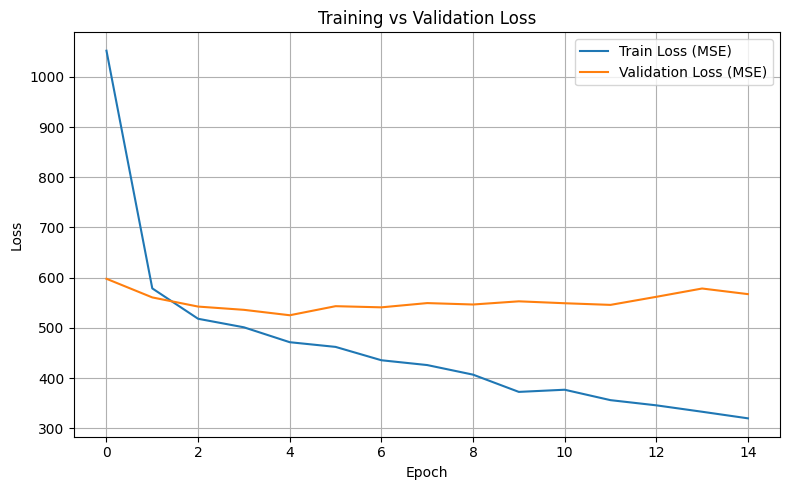

In [72]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 중앙값으로 채우기 및 스케일링
imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_val = pd.DataFrame(imputer.transform(X_val), columns=X_val.columns)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_scaled, y_val),
    verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
)

val_preds_dl = model.predict(X_val_scaled).flatten()
rmse = np.sqrt(mean_squared_error(y_val, val_preds_dl))
mae = mean_absolute_error(y_val, val_preds_dl)
r2 = r2_score(y_val, val_preds_dl)

print(f"딥러닝 성능")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

# 시각화
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 딥러닝 예측

In [73]:
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)
X_test_scaled = scaler.transform(X_test)

test_preds_dl = model.predict(X_test_scaled).flatten()

submission_df = test_df[["ID"]].copy()
submission_df["Inhibition"] = test_preds_dl

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


In [74]:
submission_df.head()

,ID,Inhibition
0,TEST_000,36.633713
1,TEST_001,53.143833
2,TEST_002,36.912086
3,TEST_003,45.156471
4,TEST_004,32.838196


In [75]:
submission_df.shape

(100, 2)

In [ ]:
submission_df.to_csv("result_3.csv", index=False)

# 예측 결과
- test1. 머신러닝, 전처리 X, 하이퍼 파라미터 동일(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42)
1. 랜덤포레스트
2. XBOOST
3. LightGBM ✅우위 - 제출결과: 0.757

- test2. 머신러닝, 중요도가 0.001 이상인 변수만 선택, 하이퍼 파라미터 동일
: 성능 오히려 떨어짐, 트리기반 모델에서는 많은 수치형 변수 유지하는게 좋음

- test3. 머신러닝, 하이퍼 파라미터 변경 시도
1. LightGBM ✅우위 - 제출결과: 0.710
: 전부 성능 떨어졌음, 기존 파라미터 유지 하는 걸로

- test4. SVM, MLP, 스케일링, 결측 중앙값으로 채움
1. SVM
: lightGBM보다 성능 떨어져서 제출 안함
2. MLP - 제출결과: 0.62
: 성능은 더 좋았으나 제출 결과 급락